### dset check 
(note: the dataset is introduced and prepared in glacier-mapping repo:    
https://github.com/Hydrological-Observation-Group/glacier-mapping.git)
1. check pair-wise image and truth 
2. check the distribution of the dset. 

In [5]:
import numpy as np
from glob import glob
import rasterio as rio
import geopandas as gpd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from notebooks import config    
from pyrsimg import imsShow    
from pyrsimg import coor2coor    
from shapely.geometry import Point  
from matplotlib.patches import Patch


In [6]:
# colors_gla = [
#     (31/255, 36/255, 42/255),      # 非冰川：暗灰
#     (140/255, 230/255, 255/255)    # 冰川：明亮冰蓝
#     ]
colors_gla = ['#f0f0f0', '#00bfff']
colors_dem = [(128/255, 205/255, 193/255), 
          (245/255, 245/255, 245/255),
          (223/255, 194/255, 125/255), 
          (166/255, 97/255, 26/255)]
# colors_dem = [
#     (65/255, 105/255, 225/255),   # 深湖蓝 (<3000m)
#     # (173/255, 216/255, 230/255),  # 淡蓝色 (<3000m)
#     (230/255, 220/255, 170/255),  # 草甸金 (3000-4000m)
#     (210/255, 180/255, 140/255),  # 荒漠黄 (4000-4800m)
#     (185/255, 150/255, 120/255),  # 丘陵棕 (4800-5200m)
#     (150/255, 120/255, 100/255),  # 山地褐 (5200-5500m)
#     (180/255, 175/255, 170/255),  # 裸岩灰 (5500-5800m)
#     (210/255, 210/255, 210/255),  # 积雪灰 (5800-6200m)
#     (245/255, 245/255, 245/255)   # 冰川白 (>6200m)
# ]
cmap_dem = LinearSegmentedColormap.from_list('linear color', colors_dem)
cmap_gla = ListedColormap(colors_gla)   


In [7]:
names_satellite = [path_truth.split('/')[-1][0:2] 
                          for path_truth in config.paths_truth] 
print('Number of scenes:', len(config.paths_scene)) 
print('Satellite:', names_satellite[0])  


Number of scenes: 65
Satellite: l5


#### 1. Check the pair-wise sence and truth images


data/dset/scene/scene_nor/l7_scene_08.tif


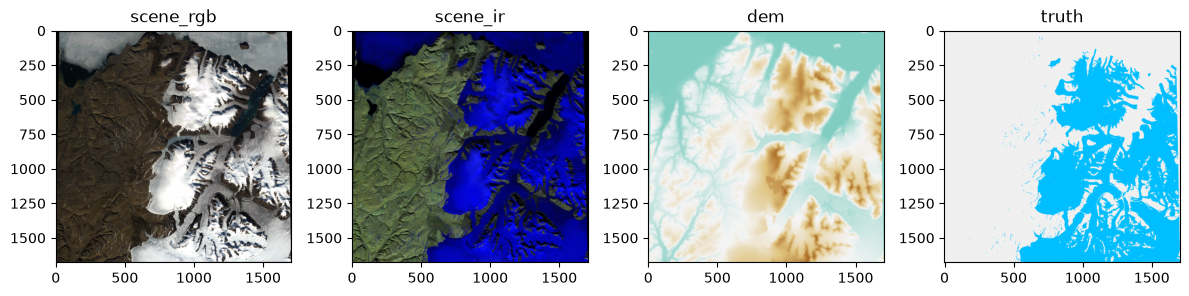

data/dset/scene/scene_nor/l7_scene_09.tif


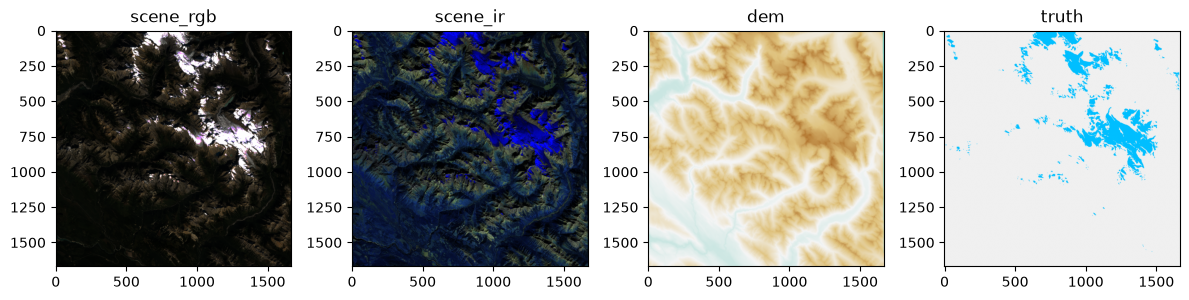

data/dset/scene/scene_nor/l7_scene_10.tif


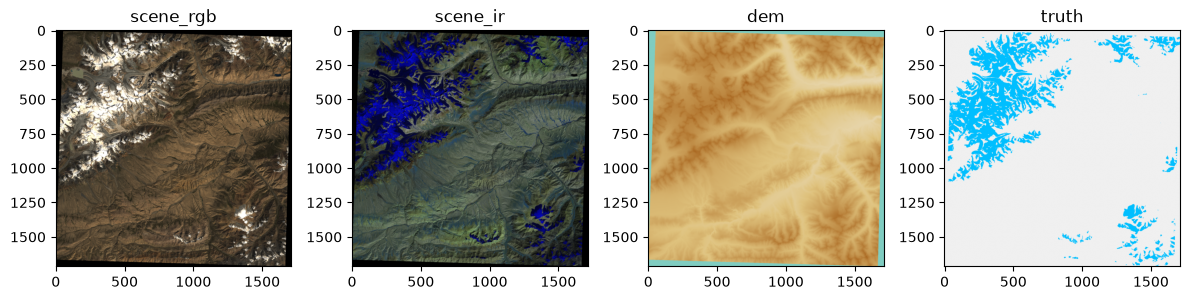

data/dset/scene/scene_nor/l7_scene_11.tif


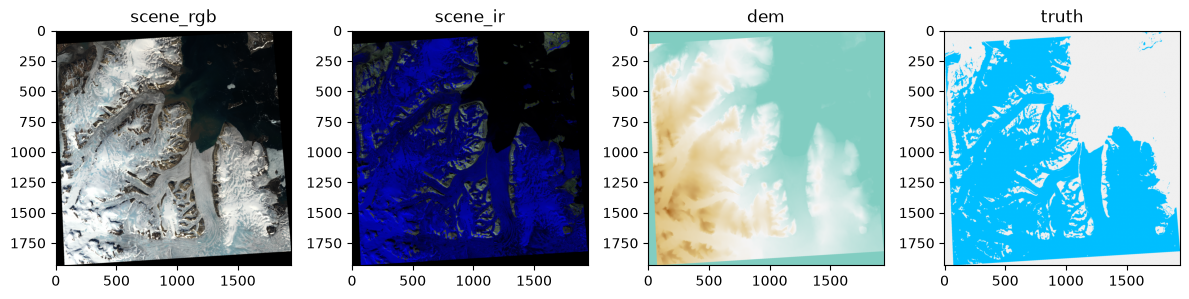

<Figure size 640x480 with 0 Axes>

In [21]:
dset = list(zip(config.paths_scene, config.paths_truth, config.paths_dem))
for path_scene, path_truth, path_dem in dset[20:24]:
        print(path_scene)
        scene_rio = rio.open(path_scene)
        dem_rio = rio.open(path_dem)
        truth_rio = rio.open(path_truth)
        scene_truth_arr = [scene_rio.read([1,2,3]).transpose(1,2,0), 
                           scene_rio.read([4,5,6]).transpose(1,2,0), 
                           dem_rio.read()[0], truth_rio.read()[0]]
        ax = imsShow(img_list=scene_truth_arr,
                img_name_list=['scene_rgb', 'scene_ir', 'dem', 'truth'], 
                clip_list=[[0,98], 0, 0, 0],
                figsize=(12,4))
        ax[2].imshow(dem_rio.read()[0], cmap=cmap_dem)        
        ax[3].imshow(truth_rio.read()[0], cmap=cmap_gla);
        plt.tight_layout()   
        plt.show() 
plt.tight_layout()


#### check the distribution of dataset

In [138]:
paths_truth_tra_vec = [path.replace('tif', 'gpkg') for path in config.paths_truth_tra]
paths_truth_val_vec = [path.replace('tif', 'gpkg') for path in config.paths_truth_val] 
paths_truth_vec = paths_truth_tra_vec + paths_truth_val_vec


In [139]:
def get_center(path_vec):
    truth_vec_gpd = gpd.read_file(path_vec)
    truth_vec_gpd_wgs84 = truth_vec_gpd.to_crs(epsg=4326, inplace=False) 
    x_min, y_min, x_max, y_max = truth_vec_gpd_wgs84.union_all().bounds 
    center = ((x_min + x_max)/2, (y_min + y_max)/2) 
    return center
scene_centers = [get_center(path) for path in paths_truth_vec]


In [140]:

# 与 paths_truth_vec 相同顺序(训练块+验证块), 避免行错位
pixel_count = [rio.open(path).read(1).size
               for path in config.paths_truth_tra + config.paths_truth_val]

dset_gdf = gpd.GeoDataFrame({
    'scene_id': [path.split('/')[-1].split('.')[0] for path in paths_truth_vec],  
    'satellite': [path.split('/')[-1][0:2] for path in paths_truth_vec],  
    'pixel_count': pixel_count,
    'tra': [path in paths_truth_tra_vec for path in paths_truth_vec],   
    'geometry': [Point(center) for center in scene_centers],    
    }, 
    crs='EPSG:4326')    
# dset_gdf.to_file('data/dset/dset.gpkg', driver='GPKG')     
dset_gdf.head()    


,scene_id,satellite,pixel_count,tra,geometry
0,l5_scene_02,l5,2975481,True,POINT (-26.10997 80.77131)
1,l5_scene_03,l5,2903360,True,POINT (-26.55014 81.76744)
2,l5_scene_04,l5,3029328,True,POINT (-17.9464 64.27999)
3,l5_scene_05,l5,2941056,True,POINT (-81.60499 74.72179)
4,l5_scene_07,l5,2915544,True,POINT (-70.74499 -54.51907)


In [141]:
# 卫星配色 (seaborn-deep, 柔和且对色觉障碍较友好; 保留原红/绿/蓝/橙/紫的色相语义)
sat_colors = {'l5': '#c44e52',   # red
              'l7': '#55a868',   # green
              'l8': '#4c72b0',   # blue
              'l9': '#dd8452',   # orange
              's2': '#8172b3'}   # purple
# 训练/验证配色 (全篇统一): 中性灰阶, 避免与卫星色相重复
split_colors = {'tra': "#2a9d8f", 'val': '#e76f51'}


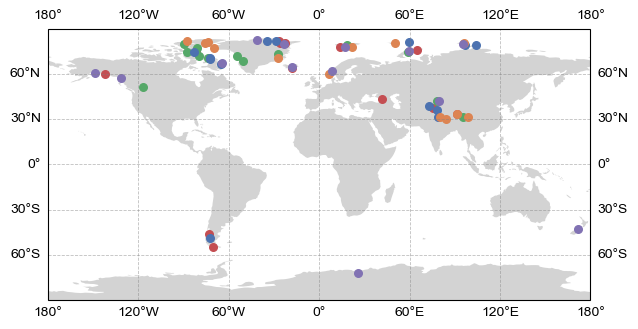

In [142]:
fig, ax = plt.subplots(figsize=(7, 5), subplot_kw={"projection": ccrs.PlateCarree()})
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.set_global()
for sat, color in sat_colors.items():
    pts = dset_gdf.loc[dset_gdf.scene_id.str[:2].eq(sat), "geometry"]
    ax.scatter(pts.x, pts.y, s=30, marker='o', color=color, label=sat, transform=ccrs.PlateCarree())
gl = ax.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=True,
    xlocs=np.arange(-180, 181, 60),
    ylocs=np.arange(-90, 91, 30),
    linewidth=0.6,
    color="gray",
    alpha=0.5,
    linestyle="--")

gl.xlabel_style = gl.ylabel_style = {"size": 10}
# ax.legend(loc=(0.03, 0.05), fontsize=9)
# fig.savefig('figures/dset_distribution.png') 


#### check the traset and valset

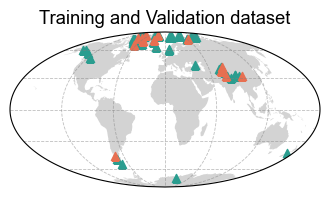

In [143]:
fig, ax = plt.subplots(figsize=(4, 3), subplot_kw={"projection": ccrs.Mollweide()})
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.set_global()
for mask, color, label in [
    (dset_gdf.tra, split_colors['tra'], "Training set"),
    (~dset_gdf.tra, split_colors['val'], "Validation set")]:
    pts = dset_gdf.loc[mask, "geometry"]
    ax.scatter(pts.x, pts.y, s=35, marker='^', color=color, label=label, transform=ccrs.PlateCarree())

ax.set_title("Training and Validation dataset")
gl = ax.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=False,
    xlocs=np.arange(-180, 181, 60),
    ylocs=np.arange(-90, 91, 30),
    linewidth=0.6,
    color="gray",
    alpha=0.5,
    linestyle="--",
)
gl.xlabel_style = gl.ylabel_style = {"size": 9}
# ax.legend(loc=(0.03, 0.05), fontsize=9)
# fig.savefig('figs/traset_valset.png', dpi=300)

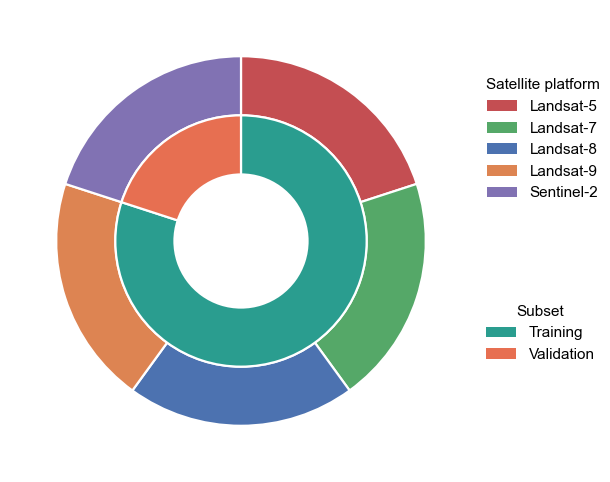

In [144]:

order = ['l5', 'l7', 'l8', 'l9', 's2']
names = ['Landsat-5', 'Landsat-7', 'Landsat-8', 'Landsat-9', 'Sentinel-2']
inner = [dset_gdf.tra.sum(), (~dset_gdf.tra).sum()]           # 内环: 训练 / 验证 幅数
outer = dset_gdf.satellite.value_counts().reindex(order)      # 外环: 各卫星 幅数

fig, ax = plt.subplots(figsize=(6, 6))
wp = dict(width=0.32, edgecolor='white', linewidth=1.6)
ax.pie(outer, radius=1.0, colors=[sat_colors[s] for s in order],
       startangle=90, counterclock=False, wedgeprops=wp)
ax.pie(inner, radius=0.68, colors=[split_colors['tra'], split_colors['val']],
       startangle=90, counterclock=False, wedgeprops=wp)

leg1 = ax.legend([Patch(fc=sat_colors[s]) for s in order], names,
                 title='Satellite platform', loc='center left', 
                 bbox_to_anchor=(1.0, 0.72), frameon=False)
ax.add_artist(leg1)
ax.legend([Patch(fc=split_colors[k]) for k in ['tra', 'val']], ['Training', 'Validation'],
          title='Subset', loc='center left', bbox_to_anchor=(1.0, 0.3), frameon=False)

# fig.savefig('figures/dset_donut.png', dpi=300, bbox_inches='tight')
